# Support Vector Machine untuk Klasifikasi Biner

Notebook ini memperlihatkan proses praktis **Support Vector Machine (SVM)** dari tahap paling dasar sampai penggunaan beberapa jenis kernel.

Fokus notebook ini hanya pada **klasifikasi biner** agar konsep SVM lebih mudah dipahami.

## 1. Import Library yang Dibutuhkan

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.datasets import make_circles, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Agar hasil eksperimen dapat direproduksi
RANDOM_STATE = 42

## 2. Dataset linear sederhana

Pertama, kita membuat dataset 2 dimensi yang **linearly separable**.

Artinya, kelas negatif dan kelas positif dapat dipisahkan dengan satu garis lurus.

Label yang digunakan:

- `-1` untuk kelas negatif
- `+1` untuk kelas positif

Penggunaan label `-1` dan `+1` umum digunakan dalam formulasi matematis SVM.

In [27]:
X_linear = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [4, 4],
    [5, 4],
    [4, 5]
], dtype=float)

y_linear = np.array([-1, -1, -1, +1, +1, +1])

df_linear = pd.DataFrame(X_linear, columns=["x1", "x2"])
df_linear["kelas"] = y_linear
df_linear

,x1,x2,kelas
0,1.0,1.0,-1
1,1.0,2.0,-1
2,2.0,1.0,-1
3,4.0,4.0,1
4,5.0,4.0,1
5,4.0,5.0,1


## 3. Visualisasi dataset linear

Karena dataset hanya memiliki dua fitur, kita dapat menggambarkannya dalam bidang 2D.

- Sumbu horizontal: `x1`
- Sumbu vertikal: `x2`
- Titik dengan label berbeda seharusnya berada pada wilayah yang berbeda.

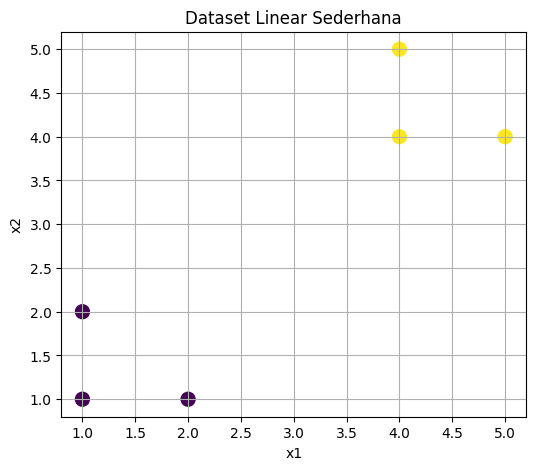

In [28]:
plt.figure(figsize=(6, 5))
plt.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, s=100)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset Linear Sederhana")
plt.grid(True)
plt.show()

## 4. Melatih SVM linear

Sekarang kita melatih model SVM dengan `kernel="linear"`.

Kita menggunakan nilai `C` yang sangat besar (`C=1e6`) untuk mendekati perilaku **hard-margin SVM**.

Mengapa?

- Pada hard-margin SVM, model berusaha memisahkan seluruh data training tanpa kesalahan.
- Pada implementasi praktis seperti `SVC`, parameter `C` mengontrol penalti terhadap kesalahan.
- Semakin besar `C`, semakin keras model menghukum kesalahan klasifikasi.

Karena dataset ini sederhana dan dapat dipisahkan secara linear, nilai `C` besar cocok untuk memperlihatkan konsep batas keputusan dan margin.

In [29]:
svm_linear = SVC(kernel="linear", C=1e6)
svm_linear.fit(X_linear, y_linear)

print("Model SVM linear berhasil dilatih.")

Model SVM linear berhasil dilatih.


## 5. Mengambil nilai `w` dan `b`

Untuk SVM linear, decision boundary ditulis sebagai:

$$
w^T x + b = 0
$$

Pada data 2D, bentuknya menjadi:

$$
w_1x_1 + w_2x_2 + b = 0
$$

Di scikit-learn:

- `coef_` menyimpan nilai vektor bobot `w`.
- `intercept_` menyimpan nilai bias/intercept `b`.

Nilai `w` menentukan arah/orientasi boundary, sedangkan `b` menggeser posisi boundary.

In [30]:
w = svm_linear.coef_[0]
b = svm_linear.intercept_[0]

print("Nilai w:", w)
print("Nilai b:", b)

print("Persamaan decision boundary:")
print(f"{w[0]:.4f} * x1 + {w[1]:.4f} * x2 + ({b:.4f}) = 0")

Nilai w: [0.39986345 0.40009103]
Nilai b: -2.199893794568352
Persamaan decision boundary:
0.3999 * x1 + 0.4001 * x2 + (-2.1999) = 0


## 6. Menurunkan persamaan garis decision boundary

Kita punya persamaan:

$$
w_1x_1 + w_2x_2 + b = 0
$$

Agar dapat digambar sebagai garis, kita ubah menjadi bentuk:

$$
x_2 = -\frac{w_1x_1 + b}{w_2}
$$

Margin SVM berada pada:

$$
w^T x + b = +1
$$

dan

$$
w^T x + b = -1
$$

Sehingga garis margin dapat ditulis:

$$
x_2 = \frac{1 - w_1x_1 - b}{w_2}
$$

dan

$$
x_2 = \frac{-1 - w_1x_1 - b}{w_2}
$$

Tiga garis ini akan kita gambar:

1. Decision boundary: `score = 0`
2. Margin positif: `score = +1`
3. Margin negatif: `score = -1`

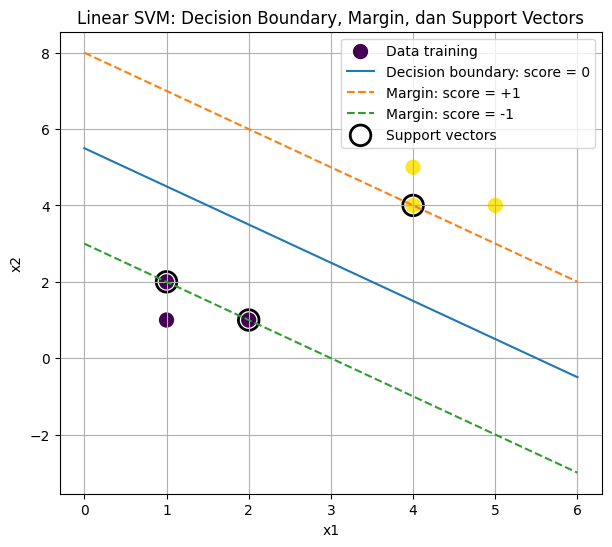

In [31]:
def line_from_score(x1_values, w, b, score=0):
    """
    Menghitung nilai x2 untuk garis:
        w1*x1 + w2*x2 + b = score

    Jika score = 0, garis tersebut adalah decision boundary.
    Jika score = +1 atau -1, garis tersebut adalah margin boundary.
    """
    w1, w2 = w

    if abs(w2) < 1e-12:
        raise ValueError("w2 terlalu dekat dengan nol, garis hampir vertikal.")

    x2_values = (score - w1 * x1_values - b) / w2
    return x2_values


x1_range = np.linspace(0, 6, 100)

boundary = line_from_score(x1_range, w, b, score=0)
margin_pos = line_from_score(x1_range, w, b, score=+1)
margin_neg = line_from_score(x1_range, w, b, score=-1)

plt.figure(figsize=(7, 6))
plt.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, s=100, label="Data training")

plt.plot(x1_range, boundary, label="Decision boundary: score = 0")
plt.plot(x1_range, margin_pos, linestyle="--", label="Margin: score = +1")
plt.plot(x1_range, margin_neg, linestyle="--", label="Margin: score = -1")

support_vectors = svm_linear.support_vectors_
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=220,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support vectors"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Linear SVM: Decision Boundary, Margin, dan Support Vectors")
plt.grid(True)
plt.legend()
plt.show()

## 7. Menghitung score dan prediksi secara manual

SVM menggunakan score:

$$
score = w^T x + b
$$

Aturan prediksi:

$$
\hat{y} =
\begin{cases}
+1, & \text{jika } score > 0 \\
-1, & \text{jika } score < 0
\end{cases}
$$

Interpretasi:

- Jika score positif, titik berada di sisi kelas `+1`.
- Jika score negatif, titik berada di sisi kelas `-1`.
- Jika score mendekati 0, titik dekat dengan decision boundary.

Kita juga menghitung jarak geometris titik ke boundary:

$$
\text{jarak} = \frac{|w^Tx+b|}{\|w\|}
$$

Jarak ini menunjukkan seberapa jauh titik dari garis pemisah.

In [32]:
scores_manual = X_linear @ w + b
pred_manual = np.where(scores_manual >= 0, +1, -1)
distance_to_boundary = np.abs(scores_manual) / np.linalg.norm(w)

df_scores = pd.DataFrame({
    "x1": X_linear[:, 0],
    "x2": X_linear[:, 1],
    "kelas_asli": y_linear,
    "score_wTx_plus_b": scores_manual,
    "prediksi_manual": pred_manual,
    "jarak_ke_boundary": distance_to_boundary
})

df_scores

,x1,x2,kelas_asli,score_wTx_plus_b,prediksi_manual,jarak_ke_boundary
0,1.0,1.0,-1,-1.399939,-1,2.474907
1,1.0,2.0,-1,-0.999848,-1,1.767599
2,2.0,1.0,-1,-1.000076,-1,1.768002
3,4.0,4.0,1,0.999924,1,1.767733
4,5.0,4.0,1,1.399788,1,2.474639
5,4.0,5.0,1,1.400015,1,2.475041


## 8. Melihat support vectors dan koefisien dual

Support vectors adalah titik-titik yang paling berpengaruh terhadap posisi decision boundary.

Pada model SVM, support vectors dapat diakses melalui:

```python
svm_linear.support_vectors_
```

Untuk model linear, scikit-learn juga menyimpan koefisien dual pada:

```python
svm_linear.dual_coef_
```

Secara konsep, hanya titik dengan kontribusi dual yang tidak nol yang menjadi support vectors.

In [33]:
print("Support vectors:")
print(svm_linear.support_vectors_)

print("\nIndeks support vectors pada data training:")
print(svm_linear.support_)

print("\nJumlah support vectors per kelas:")
print(svm_linear.n_support_)

print("\nDual coefficients:")
print(svm_linear.dual_coef_)

Support vectors:
[[1. 2.]
 [2. 1.]
 [4. 4.]]

Indeks support vectors pada data training:
[1 2 3]

Jumlah support vectors per kelas:
[2 1]

Dual coefficients:
[[-0.07988166 -0.08010924  0.1599909 ]]


## 9. Prediksi titik baru

Sekarang kita buat beberapa titik baru dan lihat bagaimana model mengklasifikasikannya.

Kita akan bandingkan:

- score manual menggunakan `w^T x + b`
- prediksi manual berdasarkan tanda score
- prediksi langsung dari model scikit-learn

In [34]:
X_new = np.array([
    [2.5, 2.5],
    [3.5, 3.0],
    [1.5, 1.5],
    [5.0, 5.0]
], dtype=float)

scores_new = X_new @ w + b
pred_new_manual = np.where(scores_new >= 0, +1, -1)
pred_new_model = svm_linear.predict(X_new)

df_new = pd.DataFrame({
    "x1": X_new[:, 0],
    "x2": X_new[:, 1],
    "score_manual": scores_new,
    "prediksi_manual": pred_new_manual,
    "prediksi_model": pred_new_model
})

df_new

,x1,x2,score_manual,prediksi_manual,prediksi_model
0,2.5,2.5,-0.200008,-1,-1
1,3.5,3.0,0.399901,1,1
2,1.5,1.5,-0.999962,-1,-1
3,5.0,5.0,1.799879,1,1


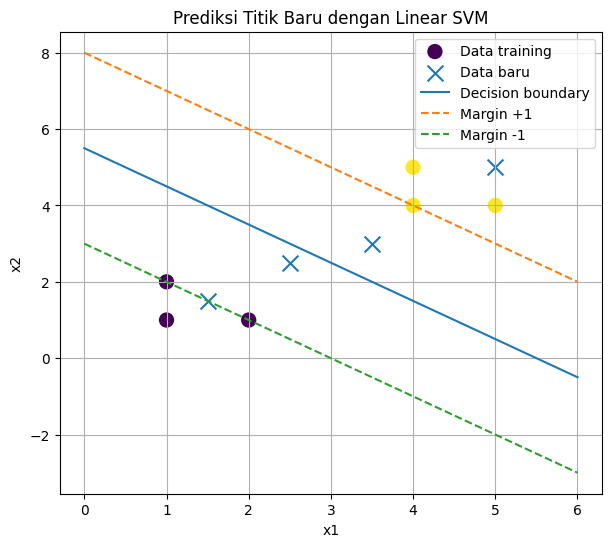

In [35]:
plt.figure(figsize=(7, 6))
plt.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, s=100, label="Data training")
plt.scatter(X_new[:, 0], X_new[:, 1], marker="x", s=130, label="Data baru")

plt.plot(x1_range, boundary, label="Decision boundary")
plt.plot(x1_range, margin_pos, linestyle="--", label="Margin +1")
plt.plot(x1_range, margin_neg, linestyle="--", label="Margin -1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Prediksi Titik Baru dengan Linear SVM")
plt.grid(True)
plt.legend()
plt.show()

# Bagian B — Kernel SVM untuk Data Non-Linear

Pada bagian sebelumnya, data dapat dipisahkan dengan garis lurus.

Sekarang kita gunakan dataset non-linear. Tujuannya adalah melihat mengapa kernel dibutuhkan.

Kita akan memakai dataset berbentuk dua lingkaran menggunakan `make_circles`.

Dataset ini tetap **klasifikasi biner**, tetapi bentuk batas keputusannya tidak cocok dipisahkan dengan garis lurus.

## 10. Membuat dataset non-linear

Dataset `make_circles` menghasilkan dua kelas berbentuk lingkaran:

- satu kelas berada di lingkaran bagian dalam,
- satu kelas berada di lingkaran bagian luar.

Dataset seperti ini baik untuk memperlihatkan keterbatasan linear SVM.

In [36]:
X_circle, y_circle = make_circles(
    n_samples=400,
    factor=0.45,
    noise=0.08,
    random_state=RANDOM_STATE
)

# Ubah label dari {0, 1} menjadi {-1, +1}
y_circle = np.where(y_circle == 0, -1, +1)

X_train, X_test, y_train, y_test = train_test_split(
    X_circle,
    y_circle,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_circle
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing :", X_test.shape[0])

Jumlah data training: 300
Jumlah data testing : 100


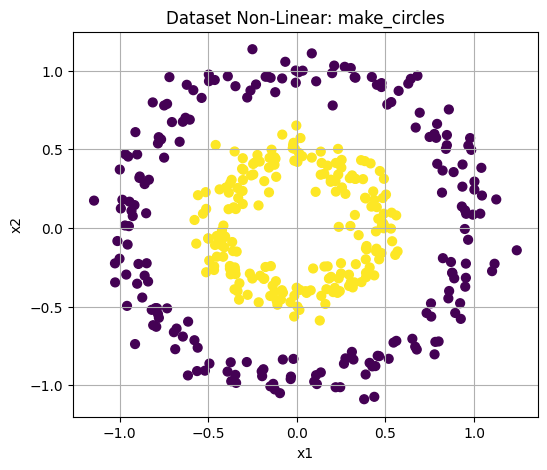

In [37]:
plt.figure(figsize=(6, 5))
plt.scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, s=40)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset Non-Linear: make_circles")
plt.grid(True)
plt.show()

## 11. Fungsi bantu untuk menggambar decision region

Fungsi berikut digunakan untuk menggambar wilayah prediksi model.

Ide dasarnya:

1. Buat banyak titik grid di area plot.
2. Prediksi kelas untuk setiap titik grid.
3. Warnai area berdasarkan prediksi model.
4. Tampilkan data asli di atasnya.

Fungsi ini akan dipakai untuk membandingkan beberapa kernel.

In [38]:
def plot_decision_region(model, X, y, title):
    """
    Menggambar decision region untuk model klasifikasi biner 2D.
    Model dapat berupa estimator biasa atau Pipeline scikit-learn.
    """
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300)
    )

    grid = np.c_[xx1.ravel(), xx2.ravel()]
    pred_grid = model.predict(grid).reshape(xx1.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx1, xx2, pred_grid, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=35)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(True)
    plt.show()

## 12. Membandingkan beberapa kernel SVM

Kita akan membandingkan empat kernel:

1. `linear`
2. `poly`
3. `rbf`
4. `sigmoid`

Setiap model dibuat sebagai `Pipeline`:

```python
StandardScaler() -> SVC()
```

Mengapa memakai scaling?

Karena SVM, terutama kernel berbasis jarak seperti RBF, sensitif terhadap skala fitur. Jika satu fitur memiliki skala jauh lebih besar dari fitur lain, jarak antar titik dapat didominasi oleh fitur tersebut.

In [39]:
kernel_configs = {
    "linear": SVC(kernel="linear", C=1.0),
    "poly": SVC(kernel="poly", degree=3, C=1.0, gamma="scale"),
    "rbf": SVC(kernel="rbf", C=1.0, gamma="scale"),
    "sigmoid": SVC(kernel="sigmoid", C=1.0, gamma="scale")
}

results = []
models = {}

for kernel_name, svm_model in kernel_configs.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", svm_model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=+1)

    results.append({
        "kernel": kernel_name,
        "accuracy": acc,
        "f1_score": f1
    })

    models[kernel_name] = pipeline

df_results = pd.DataFrame(results).sort_values(by="f1_score", ascending=False)
df_results

,kernel,accuracy,f1_score
2,rbf,1.00,1.000000
1,poly,0.58,0.704225
0,linear,0.54,0.634921
3,sigmoid,0.51,0.601626


## 13. Visualisasi decision region untuk setiap kernel

Perhatikan bentuk batas keputusan dari masing-masing kernel.

Pertanyaan yang perlu diamati:

- Apakah batas keputusan berbentuk garis lurus?
- Apakah boundary dapat mengikuti pola lingkaran?
- Apakah boundary terlihat terlalu sederhana?
- Apakah boundary terlihat terlalu rumit?

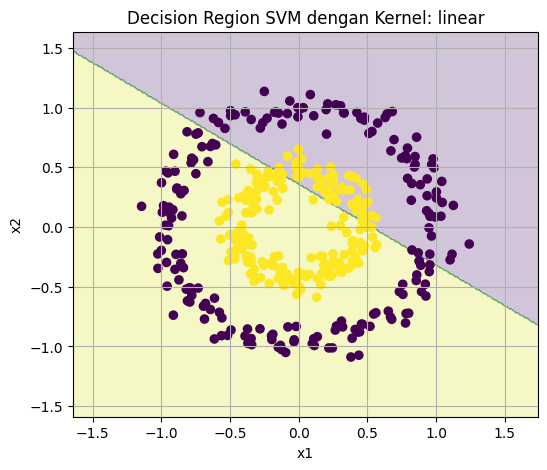

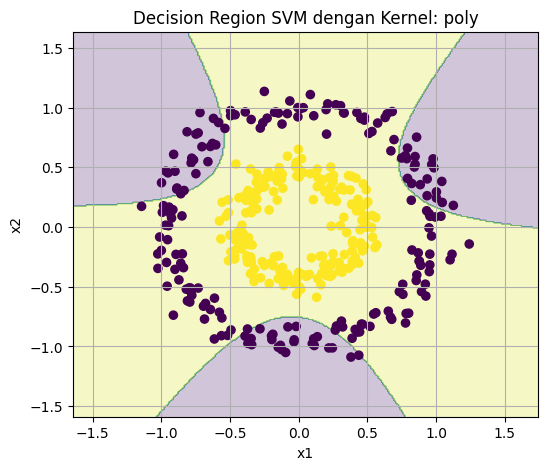

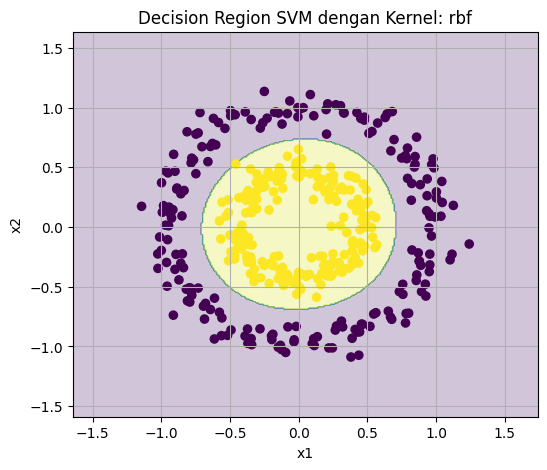

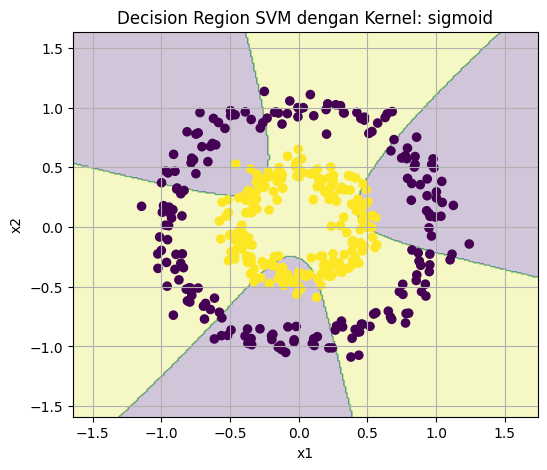

In [40]:
for kernel_name, model in models.items():
    plot_decision_region(
        model,
        X_circle,
        y_circle,
        title=f"Decision Region SVM dengan Kernel: {kernel_name}"
    )

## 14. Evaluasi detail model terbaik

Kita ambil model dengan F1-score terbaik berdasarkan hasil sebelumnya.

Kemudian kita tampilkan:

- confusion matrix,
- classification report,
- accuracy,
- F1-score.

Dalam klasifikasi biner, F1-score sering lebih informatif daripada accuracy ketika distribusi kelas tidak seimbang. Pada dataset ini kelas relatif seimbang, tetapi F1-score tetap berguna untuk memperlihatkan keseimbangan precision dan recall.

In [41]:
best_kernel = df_results.iloc[0]["kernel"]
best_model = models[best_kernel]

y_pred_best = best_model.predict(X_test)

print("Kernel terbaik berdasarkan F1-score:", best_kernel)
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification report:")
print(classification_report(y_test, y_pred_best))

Kernel terbaik berdasarkan F1-score: rbf

Confusion matrix:
[[50  0]
 [ 0 50]]

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



# Bagian C — RBF Kernel dan Hyperparameter `C` serta `gamma`

RBF kernel sering digunakan ketika pola data non-linear dan kita tidak tahu bentuk boundary yang sesuai.

Rumus RBF kernel:

$$
K(x, z) = \exp(-\gamma \|x-z\|^2)
$$

Interpretasi:

- `gamma` kecil: pengaruh satu titik menyebar jauh, boundary lebih halus.
- `gamma` besar: pengaruh satu titik lebih lokal, boundary lebih fleksibel.
- `C` kecil: model lebih toleran terhadap kesalahan.
- `C` besar: model lebih keras menghukum kesalahan training.

Jadi:

- `gamma` mengatur seberapa lokal pengaruh titik.
- `C` mengatur seberapa keras model menghindari kesalahan.

## 15. Eksperimen efek gamma

Kita latih beberapa model RBF dengan nilai `gamma` berbeda, sementara `C` dibuat tetap.

Amati bentuk decision region:

- Gamma terlalu kecil biasanya menghasilkan boundary sangat halus.
- Gamma terlalu besar dapat membuat boundary terlalu mengikuti data training.

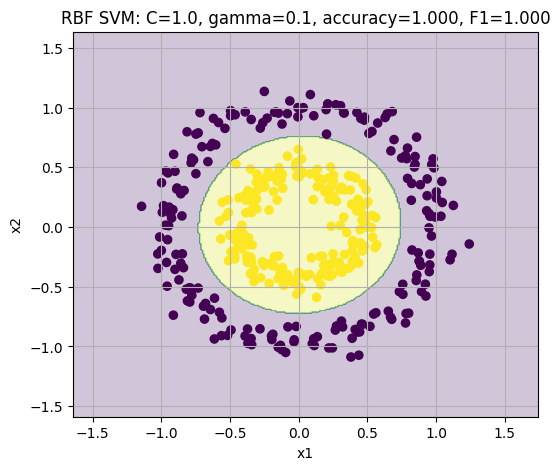

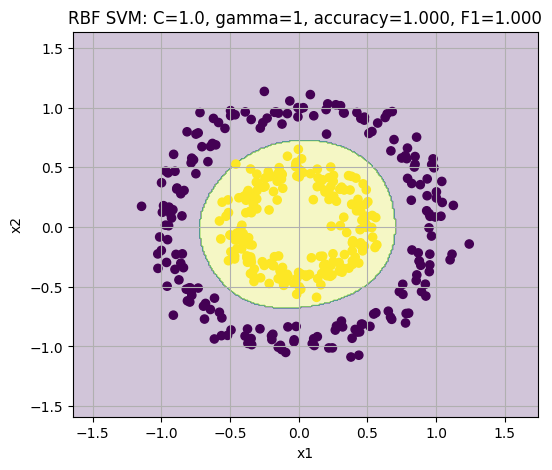

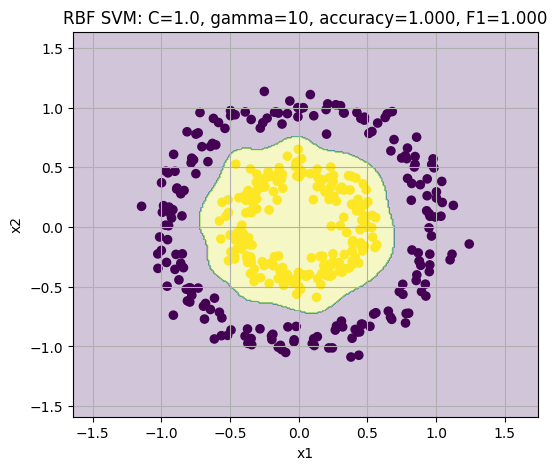

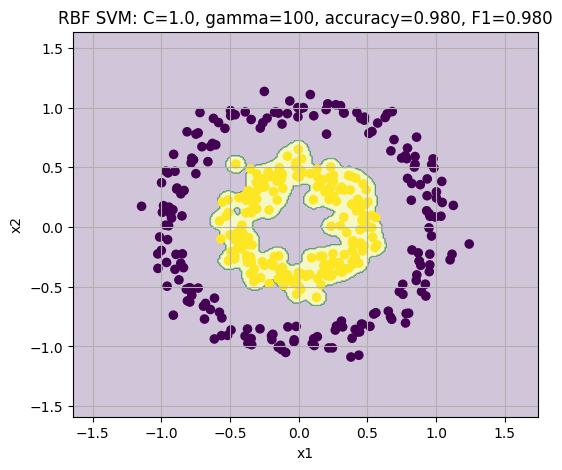

In [42]:
gamma_values = [0.1, 1, 10, 100]
C_fixed = 1.0

for gamma in gamma_values:
    model_gamma = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C_fixed, gamma=gamma))
    ])

    model_gamma.fit(X_train, y_train)
    y_pred_gamma = model_gamma.predict(X_test)

    acc = accuracy_score(y_test, y_pred_gamma)
    f1 = f1_score(y_test, y_pred_gamma, pos_label=+1)

    plot_decision_region(
        model_gamma,
        X_circle,
        y_circle,
        title=f"RBF SVM: C={C_fixed}, gamma={gamma}, accuracy={acc:.3f}, F1={f1:.3f}"
    )

## 16. Tuning sederhana dengan GridSearchCV

Daripada memilih `C` dan `gamma` secara manual, kita dapat mencoba beberapa kombinasi nilai menggunakan `GridSearchCV`.

Langkah:

1. Buat pipeline: `StandardScaler` + `SVC(kernel="rbf")`.
2. Tentukan daftar kandidat `C` dan `gamma`.
3. Lakukan cross-validation.
4. Pilih kombinasi parameter terbaik.
5. Evaluasi pada test set.

Parameter dalam pipeline ditulis dengan format:

```python
nama_step__nama_parameter
```

Karena step SVM kita bernama `"svm"`, maka parameter ditulis:

- `"svm__C"`
- `"svm__gamma"`

In [43]:
pipeline_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=pipeline_rbf,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Parameter terbaik:")
print(grid_search.best_params_)

print("\nSkor F1 rata-rata terbaik pada cross-validation:")
print(grid_search.best_score_)

Parameter terbaik:
{'svm__C': 1, 'svm__gamma': 0.1}

Skor F1 rata-rata terbaik pada cross-validation:
1.0


Evaluasi model RBF terbaik pada test set

Confusion matrix:
[[50  0]
 [ 0 50]]

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



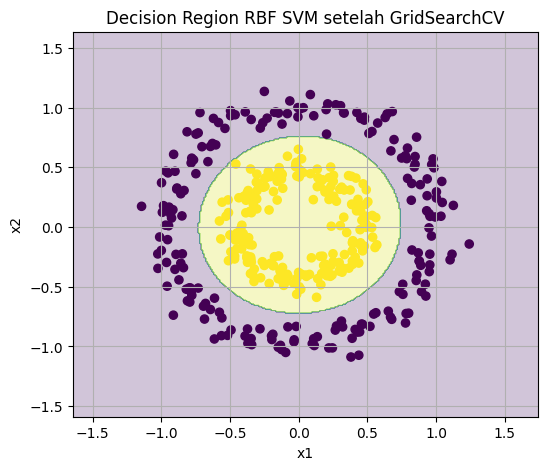

In [44]:
best_rbf_model = grid_search.best_estimator_
y_pred_grid = best_rbf_model.predict(X_test)

print("Evaluasi model RBF terbaik pada test set")
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_grid))

print("\nClassification report:")
print(classification_report(y_test, y_pred_grid))

plot_decision_region(
    best_rbf_model,
    X_circle,
    y_circle,
    title="Decision Region RBF SVM setelah GridSearchCV"
)

## 17. Ringkasan pembelajaran

Dari notebook ini, kita belajar bahwa:

1. Untuk SVM linear, decision boundary dapat ditulis sebagai:

$$
w^T x + b = 0
$$

2. Pada data 2D, boundary dapat digambar sebagai garis:

$$
x_2 = -\frac{w_1x_1 + b}{w_2}
$$

3. Margin SVM berada pada:

$$
w^T x + b = +1
$$

dan

$$
w^T x + b = -1
$$

4. Support vectors adalah titik-titik yang paling menentukan posisi boundary.

5. Kernel digunakan ketika data tidak dapat dipisahkan dengan garis lurus di ruang fitur asli.

6. RBF kernel cocok untuk pola non-linear, tetapi sangat dipengaruhi oleh `C` dan `gamma`.

7. `GridSearchCV` dapat membantu memilih kombinasi hyperparameter secara sistematis.

## Pertanyaan diskusi

1. Mengapa linear kernel gagal pada dataset berbentuk lingkaran?
2. Apa risiko jika nilai `gamma` terlalu besar?
3. Mengapa scaling fitur penting sebelum menggunakan SVM?
4. Apakah model dengan accuracy tertinggi selalu model terbaik? Jelaskan.

# Bagian D — Implementasi SVM pada Dataset Nyata

Agar lebih dekat ke penggunaan sehari-hari, berikut contoh implementasi SVM dengan `scikit-learn` pada dataset **Breast Cancer Wisconsin**.

Dataset ini bersifat klasifikasi biner:

- `0` = `malignant`
- `1` = `benign`

Karena SVM sensitif terhadap skala fitur, kita akan menggunakan pipeline `StandardScaler` + `SVC`.

## 18. Load dataset dan melihat distribusi kelas

scikit-learn menyediakan dataset ini secara bawaan, sehingga kita bisa langsung fokus pada alur modeling.

In [45]:
breast_cancer = load_breast_cancer(as_frame=True, return_X_y=False)
X_real = breast_cancer["data"]
y_real = breast_cancer["target"]
label_names = [str(name) for name in breast_cancer["target_names"]]
label_map = dict(enumerate(label_names))

print("Ukuran dataset:", X_real.shape)
print("Nama kelas:", label_names)
print("\nDistribusi kelas:")
print(y_real.value_counts().rename(index=label_map))

X_real.head()

Ukuran dataset: (569, 30)
Nama kelas: ['malignant', 'benign']

Distribusi kelas:
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 19. Training SVM dengan pipeline `StandardScaler` + `SVC`

Di bawah ini kita memisahkan data train-test, lalu melatih model SVM dengan kernel `rbf`.

Struktur pipeline ini adalah bentuk implementasi yang umum dipakai di scikit-learn karena scaling dan modeling dijalankan secara konsisten dalam satu objek.

In [46]:
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_real
)

svm_real = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
])

svm_real.fit(X_train_real, y_train_real)
y_pred_real = svm_real.predict(X_test_real)

print("Accuracy:", accuracy_score(y_test_real, y_pred_real))
print("F1-score:", f1_score(y_test_real, y_pred_real))
print("Jumlah support vector per kelas:", svm_real.named_steps["svm"].n_support_)

print("\nConfusion matrix:")
print(confusion_matrix(y_test_real, y_pred_real))

print("\nClassification report:")
print(classification_report(y_test_real, y_pred_real, target_names=label_names))

Accuracy: 0.9736842105263158
F1-score: 0.9790209790209791
Jumlah support vector per kelas: [40 44]

Confusion matrix:
[[41  1]
 [ 2 70]]

Classification report:
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 20. Contoh hasil prediksi pada beberapa data uji

Tabel berikut memperlihatkan sebagian kecil data uji beserta label aktual dan label prediksi model.

In [47]:
sample_predictions = X_test_real.head(10).copy()
sample_predictions["aktual"] = y_test_real.head(10).map(label_map)
sample_predictions["prediksi"] = pd.Series(y_pred_real, index=X_test_real.index).head(10).map(label_map)

sample_predictions[[
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "aktual",
    "prediksi"
]]

,mean radius,mean texture,mean perimeter,mean area,aktual,prediksi
256,19.550,28.77,133.60,1207.0,malignant,malignant
428,11.130,16.62,70.47,381.1,benign,benign
501,13.820,24.49,92.33,595.9,malignant,malignant
363,16.500,18.29,106.60,838.1,benign,malignant
564,21.560,22.39,142.00,1479.0,malignant,malignant
464,13.170,18.22,84.28,537.3,benign,benign
358,8.878,15.49,56.74,241.0,benign,benign
343,19.680,21.68,129.90,1194.0,malignant,malignant
516,18.310,20.58,120.80,1052.0,malignant,malignant
567,20.600,29.33,140.10,1265.0,malignant,malignant


## 21. Plot hasil klasifikasi SVM scikit-learn

Section ini menggunakan **data training, data test, dan model yang sama** dengan section 19.

Karena model dilatih dengan 30 fitur, boundary tidak bisa langsung digambar ke bidang 2D.

Agar tetap bisa divisualisasikan, data yang sama diproyeksikan ke 2 dimensi menggunakan **PCA** setelah proses scaling dari pipeline.

Plot berikut menampilkan:

- data test hasil proyeksi PCA,
- warna berdasarkan **prediksi model**,
- bentuk marker berdasarkan **kelas aktual**,
- support vectors,
- titik yang salah diklasifikasikan.

Explained variance ratio PCA: [0.44413492 0.18944618]


/Users/rudyhendrawan/Course/data-course/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/rudyhendrawan/Course/data-course/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/rudyhendrawan/Course/data-course/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/rudyhendrawan/Course/data-course/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/rudyhendrawan/Course/data-course/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.co

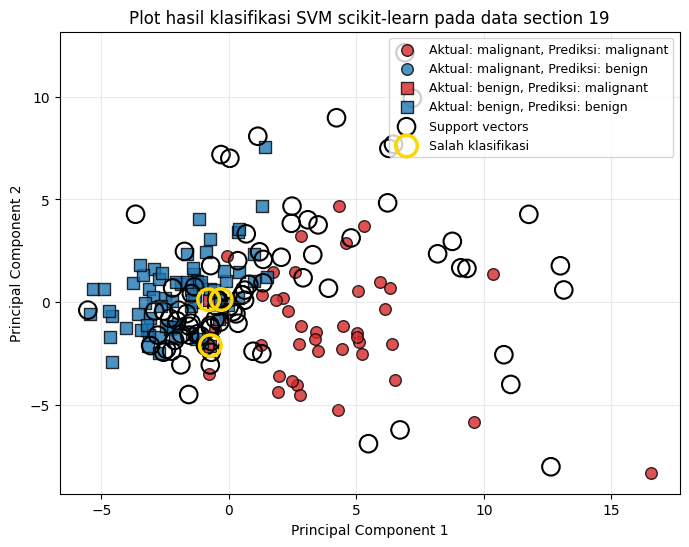

In [48]:
scaler_real = svm_real.named_steps["scaler"]
svc_real = svm_real.named_steps["svm"]

X_train_real_scaled = scaler_real.transform(X_train_real)
X_test_real_scaled = scaler_real.transform(X_test_real)
support_vectors_scaled = svc_real.support_vectors_

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_real_pca = pca.fit_transform(X_train_real_scaled)
X_test_real_pca = pca.transform(X_test_real_scaled)
support_vectors_pca = pca.transform(support_vectors_scaled)

plot_df = pd.DataFrame({
    "PC1": X_test_real_pca[:, 0],
    "PC2": X_test_real_pca[:, 1],
    "aktual": y_test_real.to_numpy(),
    "prediksi": y_pred_real,
    "salah_klasifikasi": y_test_real.to_numpy() != y_pred_real
})

print("Explained variance ratio PCA:", pca.explained_variance_ratio_)

colors = {0: "#d62728", 1: "#1f77b4"}
markers = {0: "o", 1: "s"}

plt.figure(figsize=(8, 6))

for actual_label, marker in markers.items():
    for pred_label, color in colors.items():
        mask = (
            (plot_df["aktual"] == actual_label)
            & (plot_df["prediksi"] == pred_label)
        )
        if mask.any():
            plt.scatter(
                plot_df.loc[mask, "PC1"],
                plot_df.loc[mask, "PC2"],
                c=color,
                marker=marker,
                s=70,
                edgecolor="black",
                alpha=0.8,
                label=f"Aktual: {label_names[actual_label]}, Prediksi: {label_names[pred_label]}"
            )

plt.scatter(
    support_vectors_pca[:, 0],
    support_vectors_pca[:, 1],
    s=160,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support vectors"
)

wrong_mask = plot_df["salah_klasifikasi"]
if wrong_mask.any():
    plt.scatter(
        plot_df.loc[wrong_mask, "PC1"],
        plot_df.loc[wrong_mask, "PC2"],
        s=240,
        facecolors="none",
        edgecolors="gold",
        linewidths=2.5,
        label="Salah klasifikasi"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Plot hasil klasifikasi SVM scikit-learn pada data section 19")
plt.legend(loc="best", fontsize=9)
plt.grid(alpha=0.25)
plt.show()